# Cartesian Tensors and Point Group Symmetry

**6.7970/8.750 Symmetry and its Application to Machine Learning**

Companion notebook to the [O(3) and Spherical Harmonics notes](https://symm4ml.mit.edu/notes/o3-and-spherical-harmonics).

This lecture builds on the previous one ([O(3), spherical harmonics, and branching](https://colab.research.google.com/github/atomicarchitects/symm4ml-colabs/blob/main/lecture_o3_spherical_harmonics.ipynb)). We now turn to **Cartesian tensors** &mdash; tensors whose indices span $(x, y, z)$ &mdash; and ask:

1. How does an order-$n$ Cartesian tensor decompose into $O(3)$ irreps?
2. How do **index symmetries** (e.g. $T_{ij} = T_{ji}$) constrain that decomposition?
3. Once we know the $O(3)$ content, **how does point group symmetry determine which components are independent** for a physical tensor (moment of inertia, elasticity, etc.)?

The answer to (3) is: only components transforming as the **trivial irrep** of the point group survive. Combined with branching from the previous lecture, this lets us count physical degrees of freedom from pure representation theory.

In [ ]:
%%capture
!pip install pymatgen sympy
!pip install https://symm4ml.mit.edu/_static/symm4ml_s26/symm4ml/symm4ml_latest.zip

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from symm4ml import groups, linalg, rep, vis, vib_modes, lie, so3, grids
from pymatgen.symmetry.groups import PointGroup

---
## 1. Cartesian Tensors as Tensor Products of the Vector Rep

A **Cartesian tensor** of order $n$ is an array $T_{i_1 i_2 \ldots i_n}$ with each index ranging over $\{x, y, z\}$ &mdash; so $3^n$ components total. Under a rotation/reflection $g \in O(3)$, every index transforms with the vector representation `1o`:

$$T'_{abc\ldots} = R_{a a'}\, R_{b b'}\, R_{c c'} \cdots\, T_{a'b'c'\ldots}$$

Equivalently, flatten $T$ to a $3^n$-dimensional vector and apply the $n$-fold tensor product of `1o`:

$$\rho^{\text{order } n} = \underbrace{1o \otimes 1o \otimes \cdots \otimes 1o}_{n \text{ times}}$$

So decomposing a Cartesian tensor into $O(3)$ irreps is *exactly* decomposing $1o^{\otimes n}$. Recall $1o \otimes 1o = 0e \oplus 1e \oplus 2e$ from the previous lecture.

In [2]:
# Build O(3) irreps as in the previous lecture (skim)
so3_irreps = lie.infer_irreps_from_tensor_products(so3.so3_gens, 5)

np.random.seed(42)
N = 10
rand_rots = np.random.rand(N, 3) * 2 * np.pi
rand_signs = np.array([1] * (N // 2) + [-1] * (N // 2))

o3_irreps = []
o3_irrep_labels = []
for l, so3_ir in enumerate(so3_irreps):
    for p_label, p in [('e', 1), ('o', -1)]:
        rot_params, sign_params = so3.vec_3d_rep_to_rot_and_sign_params(
            np.array([s * so3.axis_angle_to_matrix(r / np.linalg.norm(r), np.linalg.norm(r))
                      for s, r in zip(rand_signs, rand_rots)])
        )
        o3_irreps.append(so3.o3_irrep(so3_ir, rot_params, sign_params, parity=p))
        o3_irrep_labels.append(f'{l}{p_label}')

print('O(3) irreps:', o3_irrep_labels)

# Build n-fold tensor products of 1o
o3_1o = o3_irreps[o3_irrep_labels.index('1o')]
o3_1o_1o = rep.tensor_product(o3_1o, o3_1o)
o3_1o_1o_1o = rep.tensor_product(o3_1o_1o, o3_1o)
o3_1o_1o_1o_1o = rep.tensor_product(o3_1o_1o, o3_1o_1o)

O(3) irreps: ['0e', '0o', '1e', '1o', '2e', '2o', '3e', '3o', '4e', '4o']


### Decomposition without index symmetry

A general (asymmetric) order-$n$ Cartesian tensor has $3^n$ degrees of freedom &mdash; matching the dimension of $1o^{\otimes n}$. Let's decompose orders 2, 3, 4.

In [3]:
def decompose(tp_rep, label):
    print(f'{label} (dim {tp_rep.shape[1]}):')
    for irrep_label, ir in zip(o3_irrep_labels, o3_irreps):
        cob = linalg.infer_change_of_basis(tp_rep, ir)
        if cob.shape[0] > 0:
            print(f'  {irrep_label}: {cob.shape[0]} copies')
    print()

decompose(o3_1o_1o,           '1o ⊗ 1o')
decompose(o3_1o_1o_1o,        '1o ⊗ 1o ⊗ 1o')
decompose(o3_1o_1o_1o_1o,     '1o ⊗ 1o ⊗ 1o ⊗ 1o')

1o ⊗ 1o (dim 9):
  0e: 1 copies
  1e: 1 copies
  2e: 1 copies

1o ⊗ 1o ⊗ 1o (dim 27):
  0o: 1 copies
  1o: 3 copies
  2o: 2 copies
  3o: 1 copies

1o ⊗ 1o ⊗ 1o ⊗ 1o (dim 81):
  0e: 3 copies
  1e: 6 copies
  2e: 6 copies
  3e: 3 copies
  4e: 1 copies



Reading the output:
- **Order 2** (9 d.o.f.) $= 0e \oplus 1e \oplus 2e$ &mdash; scalar + pseudovector + symmetric traceless tensor
- **Order 3** (27 d.o.f.) $= 0o \oplus 3 \cdot 1o \oplus 2 \cdot 2o \oplus 3o$ &mdash; everything is odd parity (three odd inputs)
- **Order 4** (81 d.o.f.) $= 3 \cdot 0e \oplus 6 \cdot 1e \oplus 6 \cdot 2e \oplus 3 \cdot 3e \oplus 4e$ &mdash; back to even parity

---
## 2. Index Symmetries Reduce the Decomposition

Most physical tensors have **index symmetries** that reduce the number of independent components. For example:

- **Symmetric matrix** $M_{ij} = M_{ji}$: 6 d.o.f. (not 9)
- **Antisymmetric matrix** $M_{ij} = -M_{ji}$: 3 d.o.f. (the cross product)
- **Levi-Civita** $\epsilon_{ijk}$: 1 d.o.f. (it's a pseudoscalar)
- **Elasticity tensor** $C^{ijkl}$ with $ij = ji$, $kl = lk$, $ijkl = klij$: 21 d.o.f. (not 81)

To impose an index symmetry, we project onto the subspace of tensors satisfying it. The recipe in three steps:

1. `grids.formula_to_perm_and_sign_group('ij=ji')` &rarr; build the permutation/sign group on indices
2. `grids.perm_to_grid_rep(...)` &rarr; lift this to a permutation rep on the flattened $3^n$ tensor entries
3. `grids.perm_and_sign_to_tensor_basis_and_proj(...)` &rarr; build the orthogonal basis for the invariant subspace

### Symmetric rank-2 tensor: $ij = ji$

In [4]:
perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ij=ji')
new_basis, new_proj = grids.perm_and_sign_to_tensor_basis_and_proj(perm_rep, sign_rep, [3, 3])
print(f'Symmetric subspace: {new_basis.shape[0]} of 9 = {new_basis.shape[0]} d.o.f.')

# Project the O(3) tensor rep onto this subspace and decompose
sub = np.einsum('ij,njk,kl->nil', new_basis, o3_1o_1o, new_basis.T)
print('\nSymmetric matrix decomposes as:')
for label, ir in zip(o3_irrep_labels, o3_irreps):
    cob = linalg.infer_change_of_basis(sub, ir)
    if cob.shape[0] > 0:
        print(f'  {label}: {cob.shape[0]} copies')
print('\n→ 0e ⊕ 2e  (the 1e antisymmetric piece is gone!)')

Symmetric subspace: 6 of 9 = 6 d.o.f.

Symmetric matrix decomposes as:
  0e: 1 copies
  2e: 1 copies

→ 0e ⊕ 2e  (the 1e antisymmetric piece is gone!)


### Antisymmetric rank-2 tensor: $ij = -ji$

In [5]:
perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ij=-ji')
new_basis, new_proj = grids.perm_and_sign_to_tensor_basis_and_proj(perm_rep, sign_rep, [3, 3])
print(f'Antisymmetric subspace: {new_basis.shape[0]} of 9 = {new_basis.shape[0]} d.o.f.')

sub = np.einsum('ij,njk,kl->nil', new_basis, o3_1o_1o, new_basis.T)
print('\nAntisymmetric matrix decomposes as:')
for label, ir in zip(o3_irrep_labels, o3_irreps):
    cob = linalg.infer_change_of_basis(sub, ir)
    if cob.shape[0] > 0:
        print(f'  {label}: {cob.shape[0]} copies')
print('\n→ 1e (a pseudovector — exactly the cross product!)')

Antisymmetric subspace: 3 of 9 = 3 d.o.f.

Antisymmetric matrix decomposes as:
  1e: 1 copies

→ 1e (a pseudovector — exactly the cross product!)


### Fully symmetric rank-3 tensor: $ijk = jik = ikj$

In [6]:
perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ijk=jik=ikj')
new_basis, _ = grids.perm_and_sign_to_tensor_basis_and_proj(perm_rep, sign_rep, [3, 3, 3])
print(f'Fully symmetric rank-3: {new_basis.shape[0]} of 27 d.o.f.')

sub = np.einsum('ij,njk,kl->nil', new_basis, o3_1o_1o_1o, new_basis.T)
print('\nDecomposes as:')
for label, ir in zip(o3_irrep_labels, o3_irreps):
    cob = linalg.infer_change_of_basis(sub, ir)
    if cob.shape[0] > 0:
        print(f'  {label}: {cob.shape[0]} copies')
print('\n→ 1o ⊕ 3o  (a vector + the degree-3 spherical harmonic part)')

Fully symmetric rank-3: 10 of 27 d.o.f.

Decomposes as:
  1o: 1 copies
  3o: 1 copies

→ 1o ⊕ 3o  (a vector + the degree-3 spherical harmonic part)


### Fully antisymmetric rank-3 tensor: $ijk = -jik = -ikj$ (Levi-Civita)

In [7]:
perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ijk=-jik=-ikj')
new_basis, _ = grids.perm_and_sign_to_tensor_basis_and_proj(perm_rep, sign_rep, [3, 3, 3])
print(f'Fully antisymmetric rank-3: {new_basis.shape[0]} of 27 d.o.f.')

sub = np.einsum('ij,njk,kl->nil', new_basis, o3_1o_1o_1o, new_basis.T)
print('\nDecomposes as:')
for label, ir in zip(o3_irrep_labels, o3_irreps):
    cob = linalg.infer_change_of_basis(sub, ir)
    if cob.shape[0] > 0:
        print(f'  {label}: {cob.shape[0]} copies')
print('\n→ 0o (a single pseudoscalar — the Levi-Civita symbol!)')

Fully antisymmetric rank-3: 1 of 27 d.o.f.

Decomposes as:
  0o: 1 copies

→ 0o (a single pseudoscalar — the Levi-Civita symbol!)


### Elasticity tensor: $ijkl = jikl = ijlk = klij$ &mdash; the famous 21 components

In [8]:
perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ijkl=jikl=ijlk=klij')
new_basis, _ = grids.perm_and_sign_to_tensor_basis_and_proj(perm_rep, sign_rep, [3, 3, 3, 3])
print(f'Elasticity tensor symmetry: {new_basis.shape[0]} of 81 d.o.f.')

sub = np.einsum('ij,njk,kl->nil', new_basis, o3_1o_1o_1o_1o, new_basis.T)
print('\nDecomposes as:')
for label, ir in zip(o3_irrep_labels, o3_irreps):
    cob = linalg.infer_change_of_basis(sub, ir)
    if cob.shape[0] > 0:
        print(f'  {label}: {cob.shape[0]} copies')
print('\n→ 2 · 0e ⊕ 2 · 2e ⊕ 1 · 4e  (= 2·1 + 2·5 + 1·9 = 21)')

Elasticity tensor symmetry: 21 of 81 d.o.f.

Decomposes as:
  0e: 2 copies
  2e: 2 copies
  4e: 1 copies

→ 2 · 0e ⊕ 2 · 2e ⊕ 1 · 4e  (= 2·1 + 2·5 + 1·9 = 21)


---
## 3. A closer look at what is happening "under the hood" (helpful for homework)

Let's look closely at the fully symmetric 3rd order tensor and the fully anti-symmetric 3rd order tensor, and more specifically  

### 3a. First we'll look at the permutation and sign representation for the formula `ijk=jik=ikj`

Note that this is the familiar group $P(3)$ for the permutations. The sign representation is constant over all permutations (no minuses in formula).

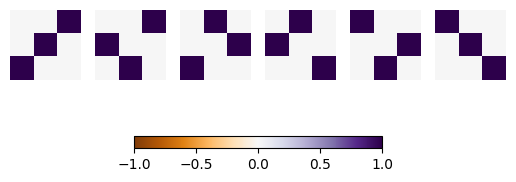

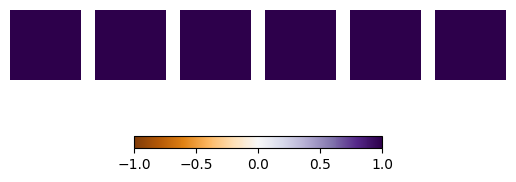

In [9]:
perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ijk=jik=ikj')
vis.plot_matrices(perm_rep, cmap='PuOr');
vis.plot_matrices(sign_rep.reshape(-1, 1, 1), cmap='PuOr');

### Next we look at how the permutation rep on indices applies to swaps over the $3^3$ entries of the 3rd order tensor.

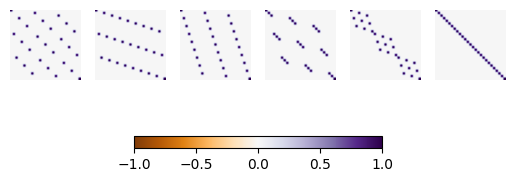

In [10]:
grid_rep = grids.perm_to_grid_rep(perm_rep, dims=[3, 3, 3])
vis.plot_matrices(grid_rep, cmap='PuOr');

### Finally, multiply this `grid_rep` by the `sign_rep` and sum over the group axis `axis=0` to get the constraints shared across all the elements.

Note that some entries remain completely independent (only have a non-zero entry at their diagonal) such as the entries (0 and 26) while other mix with other entries.

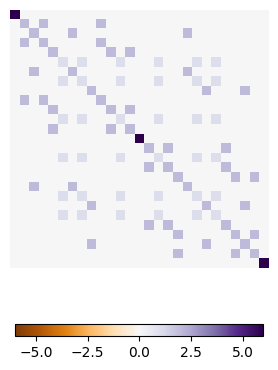

In [11]:
sum_grid_sign_rep = (grid_rep * sign_rep.reshape(-1,1,1)).sum(0)
vmax = np.abs(sum_grid_sign_rep).max()
vis.plot_matrices(sum_grid_sign_rep[np.newaxis], cmap='PuOr', vmax=vmax);

### 3b. Now let's contrast this with the antisymmetry order 3 tensor `ijk=-jik=-ikj`

We have the same P(3) `perm_rep` but now we have changes in sign.

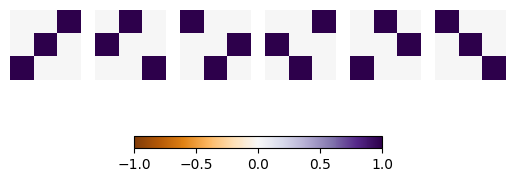

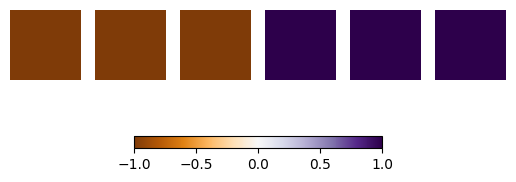

In [12]:
perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ijk=-jik=-ikj')
vis.plot_matrices(perm_rep, cmap='PuOr');
vis.plot_matrices(sign_rep.reshape(-1, 1, 1), cmap='PuOr');

### Next we look at how the permutation rep on indices applies to swaps over the $3^3$ entries of the 3rd order tensor.

This is the same as the previous case -- nothing changes since it's only the `sign_rep` that changes

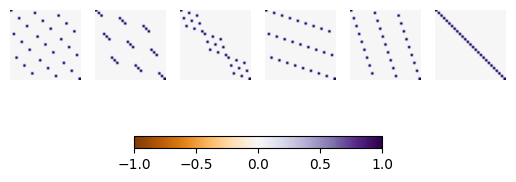

In [13]:
grid_rep = grids.perm_to_grid_rep(perm_rep, dims=[3, 3, 3])
vis.plot_matrices(grid_rep, cmap='PuOr');

### Finally, multiply this `grid_rep` by the `sign_rep` and sum over the group axis `axis=0` to get the constraints shared across all the elements.

Note that all entries are constrained to have opposite sign to other entries.

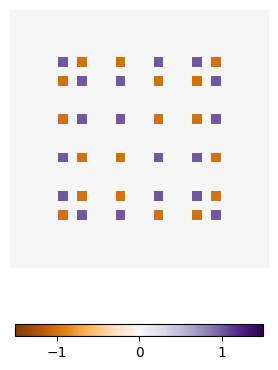

In [18]:
sum_grid_sign_rep = (grid_rep * sign_rep.reshape(-1,1,1)).sum(0)
vmax = np.abs(sum_grid_sign_rep).max()
vis.plot_matrices(sum_grid_sign_rep[np.newaxis], cmap='PuOr', vmax=vmax * 1.5); # just to make the purple and orange stand out a bit

## 3c. This `sum_grid_sign_rep` becomes the projector for the subspace of $3^3$ tensors that satisfy the index permutation formula. Apply it to the full rep of $3^3$ tensors and decompose to see which irreps survive the constraint!

---
## 4. Combining with Point Group Symmetry

We've now reduced the *index symmetry* problem: a Cartesian tensor with index constraints lives in a subspace of $O(3)$ irreps. But a *physical* tensor describing a material must additionally be **invariant under the material's point group symmetry**.

The key insight: a tensor that is invariant under the point group $G \leq O(3)$ has only the components that transform as the **trivial irrep** $A_1$ (or $A_{1g}$) of $G$. Everything else is forbidden by symmetry.

**Recipe** (synthesizing this lecture and the previous one):

1. Decompose the Cartesian tensor into $O(3)$ irreps (using index symmetry, as above)
2. **Branch** each $O(3)$ irrep to irreps of $G$ (using `branching_change_of_basis` from the previous lecture)
3. Count how many copies of $A_1$ appear &mdash; that's the number of independent physical components.

### Helper: branch and count $A_1$ copies

In [19]:
def _reorder_irreps_by_signature(irreps, probe_idxs, signatures):
    out = [None] * len(signatures)
    for ir in irreps:
        d = ir.shape[1]
        chis = tuple(round(np.trace(ir[k]).real) for k in probe_idxs)
        for j, sig in enumerate(signatures):
            if sig == (d, chis) and out[j] is None:
                out[j] = ir
                break
    return out

def get_a1_first_irreps(group_name, probe_idxs, signatures):
    """Build group + irreps reordered so that A1 (trivial) is index 0."""
    g = PointGroup(vib_modes.point_group_dict[group_name])
    G = np.stack([op.rotation_matrix for op in g.symmetry_ops], axis=0)
    G_table = groups.make_multiplication_table(G)
    np.random.seed(42)
    G_irreps_raw = rep.infer_irreps(G_table)
    G_irreps = _reorder_irreps_by_signature(G_irreps_raw, probe_idxs, signatures)
    return G, G_irreps

In [ ]:
# Td: probe with sigma_d (det=-1, trace=+1)
Td_g = PointGroup(vib_modes.point_group_dict['Td'])
Td = np.stack([op.rotation_matrix for op in Td_g.symmetry_ops], axis=0)
_dets = np.linalg.det(Td); _trs = np.trace(Td, axis1=1, axis2=2)
_Td_sd = next(i for i in range(len(Td)) if _dets[i] < 0 and abs(_trs[i] - 1) < 1e-6)
_Td_sigs = [(1, (1,)), (1, (-1,)), (2, (0,)), (3, (-1,)), (3, (1,))]
Td_labels = ['A1', 'A2', 'E', 'T1', 'T2']
_, Td_irreps = get_a1_first_irreps('Td', [_Td_sd], _Td_sigs)

# Oh: probe with sigma_h (det=-1, trace=+1) and inversion (det=-1, trace=-3)
Oh_g = PointGroup(vib_modes.point_group_dict['Oh'])
Oh = np.stack([op.rotation_matrix for op in Oh_g.symmetry_ops], axis=0)
_dets = np.linalg.det(Oh); _trs = np.trace(Oh, axis1=1, axis2=2)
_Oh_sh = next(i for i in range(len(Oh)) if _dets[i] < 0 and abs(_trs[i] - 1) < 1e-6 and abs(Oh[i, 0, 1]) < 1e-6)
_Oh_inv = next(i for i in range(len(Oh)) if abs(_trs[i] + 3) < 1e-6)
# Oh signatures: (dim, (chi(sigma_h), chi(inversion)))
_Oh_sigs = [
    (1, (1,  1)),    # A1g
    (1, (-1, 1)),    # A2g
    (2, (0,  2)),    # Eg
    (3, (-1, 3)),    # T1g
    (3, (1,  3)),    # T2g
    (1, (-1, -1)),   # A1u
    (1, (1, -1)),    # A2u
    (2, (0,  -2)),   # Eu
    (3, (1,  -3)),   # T1u
    (3, (-1, -3)),   # T2u
]
Oh_labels = ['A1g', 'A2g', 'Eg', 'T1g', 'T2g', 'A1u', 'A2u', 'Eu', 'T1u', 'T2u']
_, Oh_irreps = get_a1_first_irreps('Oh', [_Oh_sh, _Oh_inv], _Oh_sigs)

print(f'Td: {[ir.shape[1] for ir in Td_irreps]} matches {Td_labels}')
print(f'Oh: {[ir.shape[1] for ir in Oh_irreps]} matches {Oh_labels}')

### Independent components of a symmetric rank-2 tensor (e.g. moment of inertia)

A symmetric rank-2 tensor decomposes as $0e \oplus 2e$ under $O(3)$ (6 components, before point group constraints). Under different point groups, branching tells us how many independent components survive.

In [ ]:
# Build the symmetric rank-2 subspace as before
perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ij=ji')
new_basis, _ = grids.perm_and_sign_to_tensor_basis_and_proj(perm_rep, sign_rep, [3, 3])

def count_a1_for_tensor(group_vec, group_irreps, group_labels, sub_basis, parent_rep):
    """Count how many components of `parent_rep` projected into `sub_basis`
    transform as the trivial (A1 / A1g) irrep of the given point group."""
    sub = np.einsum('ij,njk,kl->nil', sub_basis, parent_rep, sub_basis.T)
    sub_on_G = sub[:len(group_vec)]  # would need element matching for true subgroup; here parent_rep already over G
    # For each parent O(3) irrep that appears, branch to G and count A1 multiplicity
    # Easier: directly count the A1 multiplicity in `sub` restricted to G
    # We need to evaluate sub on G_elements, which means parent_rep must be sampled at G
    pass

# Cleanest: build O(3) on Td/Oh elements and project to symmetric subspace
def build_o3_on_pg(pg_vec):
    rot_params, sign_params = so3.vec_3d_rep_to_rot_and_sign_params(pg_vec)
    return [
        so3.o3_irrep(so3_irreps[l], rot_params, sign_params, parity=p)
        for l in range(5) for p in [1, -1]
    ]

def count_independent_components(pg_vec, pg_irreps, pg_labels, basis, formula_label):
    o3_on_pg = build_o3_on_pg(pg_vec)
    # 1o⊗1o⊗...⊗1o on pg
    n = basis.shape[1]  # e.g. 9 for rank 2
    n_indices = int(round(np.log(n) / np.log(3)))
    rho = o3_on_pg[3]  # 1o
    for _ in range(n_indices - 1):
        rho = rep.tensor_product(rho, o3_on_pg[3])
    sub = np.einsum('ij,njk,kl->nil', basis, rho, basis.T)
    # Project onto trivial irrep (A1) of pg
    a1 = pg_irreps[0]
    cob = linalg.infer_change_of_basis(sub, a1)
    return cob.shape[0]

print('Symmetric rank-2 tensor (e.g. moment of inertia, dielectric):')
print(f'  Independent components under Td:  {count_independent_components(Td, Td_irreps, Td_labels, new_basis, "ij=ji")}')
print(f'  Independent components under Oh:  {count_independent_components(Oh, Oh_irreps, Oh_labels, new_basis, "ij=ji")}')

Both $T_d$ and $O_h$ give **1 independent component** for a symmetric rank-2 tensor: only the isotropic ($0e$, scalar) part survives. The 5 traceless components ($2e$) branch as $E + T_2$ under $T_d$ and $E_g + T_{2g}$ under $O_h$ &mdash; neither contains $A_1$.

Physically: the moment-of-inertia tensor of a molecule with $T_d$ or $O_h$ symmetry (methane, $\text{SF}_6$) is a multiple of the identity. The molecule has only a single moment of inertia.

### Independent components of the elasticity tensor

The elasticity tensor decomposes as $2 \cdot 0e \oplus 2 \cdot 2e \oplus 1 \cdot 4e$ under $O(3)$ (21 components). Under cubic symmetry $O_h$:

In [ ]:
perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ijkl=jikl=ijlk=klij')
elastic_basis, _ = grids.perm_and_sign_to_tensor_basis_and_proj(perm_rep, sign_rep, [3, 3, 3, 3])

print(f'Elasticity tensor:')
print(f'  21 components from index symmetry alone (no point group)')
print(f'  Under Oh: {count_independent_components(Oh, Oh_irreps, Oh_labels, elastic_basis, "elastic")} independent constants')
print(f'  Under Td: {count_independent_components(Td, Td_irreps, Td_labels, elastic_basis, "elastic")} independent constants')

**3 independent elastic constants under cubic symmetry (crystals with point groups $T$, $T_h$, $T_d$, $O$, $O_h$)** &mdash; this is the famous result that cubic crystals (like silicon, NaCl) need only 3 elastic constants ($C_{11}, C_{12}, C_{44}$) instead of the 21 that index symmetry alone allows.

The 3 surviving $A_{1g}$ components come from:
- 2 copies of $0e$ (both branch to $A_{1g}$, multiplicity 2)
- 1 copy of $4e$ (branches to $A_{1g} \oplus E_g \oplus T_{2g}$, multiplicity 1)
- The 2 copies of $2e$ branch to $E_g \oplus T_{2g}$ (no $A_{1g}$, multiplicity 0)

Total: $2 + 1 + 0 = 3$ independent elastic constants. ✓

---
## 5. Summary

We've connected three layers of representation theory:

1. **Cartesian tensors** = $\rho^{\text{vec} \otimes n}$ &mdash; an order-$n$ tensor decomposes into $O(3)$ irreps via repeated CG.
2. **Index symmetries** project onto an invariant subspace of the permutation/sign group acting on indices &mdash; this *removes* certain irreps (e.g. symmetric matrices lose the $1e$ piece, antisymmetric ones keep only $1e$).
3. **Point group symmetry** of a physical system selects the **trivial irrep** of the point group from the remaining $O(3)$ content &mdash; the number of $A_1$ copies is the number of independent components.

The full chain &mdash; index symmetry $\to$ $O(3)$ decomposition $\to$ branching to $G$ $\to$ count $A_1$ &mdash; explains why:

- A diagonal moment-of-inertia tensor for $\text{CH}_4$ has 1 independent value (not 6)
- A cubic crystal's elasticity needs 3 elastic constants (not 21)
- An isotropic material's elasticity needs 2 (Young's modulus + Poisson's ratio)
- The Levi-Civita tensor is a single pseudoscalar (not 27 numbers)

Representation theory does the bookkeeping that physical intuition would otherwise have to brute-force.